# Sistema de predicción de ventas

#### El objetivo de este proyecto es estimar la evolución del ritmo de ventas en los próximos meses, con el fin de determinar el espacio de almacenamiento necesario para reubicar el almacén de la empresa en una nueva localización. Esta estimación se basa en la tendencia creciente de ventas desde la creación de la empresa

### 1. Exportacion de Librerias necesarias, descarga y exploracion del Dataset 

In [56]:
# Librerias necesarias 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
import warnings
import itertools
import statsmodels.api as sm
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller
from IPython.display import display
import itertools
import statsmodels.api as sm

In [57]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"
df = pd.read_csv(url)

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


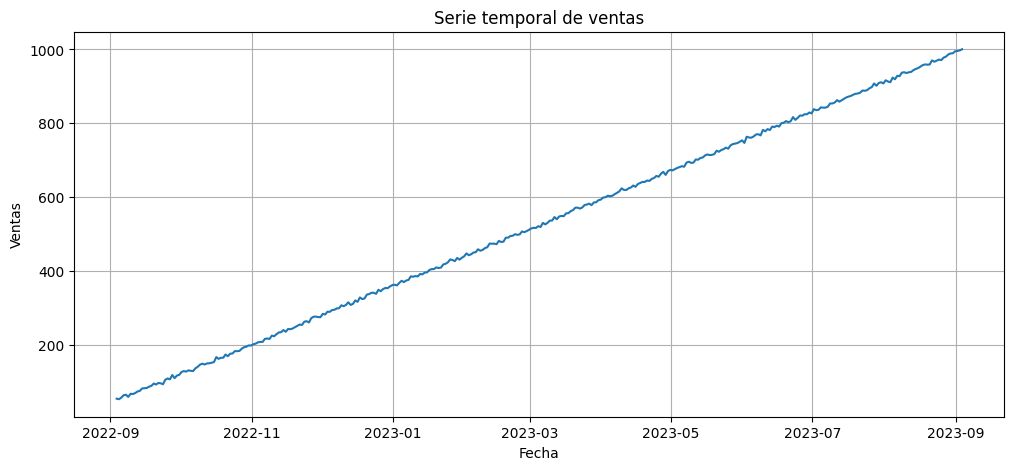

In [58]:
#Preprocesado y visualización inicial
# Convertir y ordenar
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

# Mostrar info básica
display(df.head())
display(df.describe())

# Tensor (unidad mínima entre timestamps)
tensor = df.index.to_series().diff().min()
# Mostrar tensor (Jupyter mostrará el Timedelta)
tensor

# Gráfica de la serie completa
plt.figure(figsize=(12,5))
plt.plot(df.index, df['sales'])
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()


- La primera tabla con fechas y ventas.

Son las primeras 5 filas de este DataFrame, que muestran:

Índice (date): la fecha y hora exacta de cada registro (en tu caso, un registro por día, siempre a la misma hora).

Columna sales: las ventas registradas ese día (valor numérico).

- La segunada tabla "describe()" nos dice esto del negocio:

Hay tendencia de crecimiento, porque empezo con valores alrededor de 50–60 y llego a ~1000.

Alta variabilidad: algunos días se vende  muy poco y otros muchísimo (esto se ve por el alto std y la gran diferencia entre el mínimo y el máximo).

No parece haber ventas negativas ni valores nulos, lo cual es bueno para modelar.

Explicación: la salida tensor te indica la unidad mínima (por ejemplo 1 days 00:00:00 = diario). La gráfica te permite ver si hay tendencia.



### Comprobar estacionariedad (ADF)

Qué hace: ejecuta el test ADF (Dickey–Fuller aumentado) y devuelve las estadísticas relevantes (ADF, p-value, valores críticos).


In [59]:
adf_res = adfuller(df['sales'])
adf_out = {
    "adf_stat": adf_res[0],
    "p_value": adf_res[1],
    "n_lags": adf_res[2],
    "n_obs": adf_res[3],
    "critical_values": adf_res[4]
}
adf_out

{'adf_stat': np.float64(0.545414193706378),
 'p_value': np.float64(0.9861899815311064),
 'n_lags': 13,
 'n_obs': 352,
 'critical_values': {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)}}

La serie tiene tendencia y posiblemente variabilidad creciente p_value: 0.9861 → muy superior a 0.05, por lo que no es estacionaria.

### ACF y PACF 
Qué hace: dibuja la ACF y PACF para orientación en la elección de p y q.

<Figure size 1200x400 with 0 Axes>

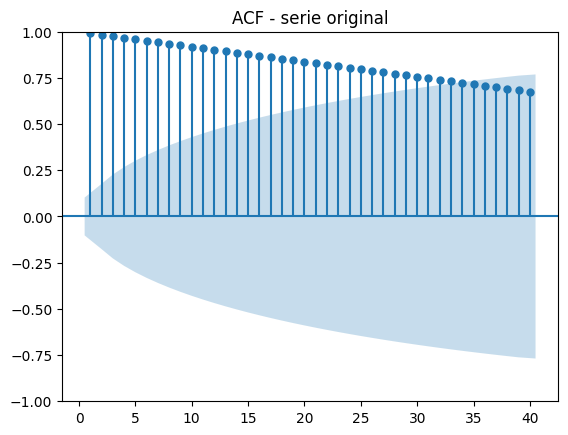

<Figure size 1200x400 with 0 Axes>

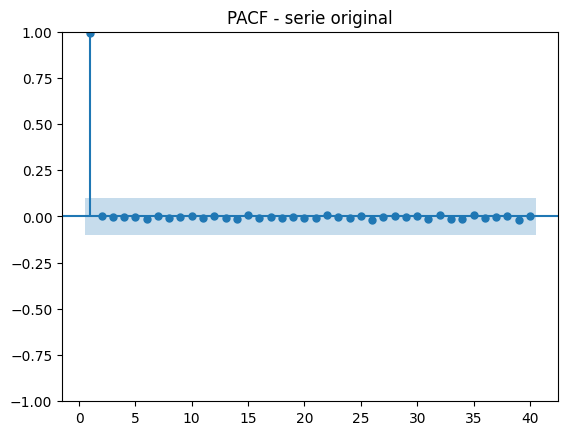

In [60]:
plt.figure(figsize=(12,4))
plot_acf(df['sales'], lags=40, zero=False)
plt.title("ACF - serie original")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df['sales'], lags=40, zero=False, method='ywm')
plt.title("PACF - serie original")
plt.show()

ACF: La gráfica muestra una caída lenta y prolongada de la autocorrelación, manteniéndose alta incluso a retardos grandes. Esto indica que la serie tiene una fuerte tendencia y no es estacionaria. El hecho de que las barras salgan de la zona azul (intervalo de confianza) confirma autocorrelación significativa.

PACF: La primera barra (lag 1) es muy alta y significativa, pero después prácticamente todas caen dentro de la zona azul. Esto sugiere que gran parte de la dependencia temporal se explica con el primer retardo y que el resto no aporta correlaciones directas adicionales.

### División Train / Test
Qué hace: divide la serie en entrenamiento (80%) y test (20%). Devuelve las formas (shapes) para confirmación.

In [61]:
# División train/test (80/20)
train_size = int(len(df) * 0.8)
train = df['sales'].iloc[:train_size]
test = df['sales'].iloc[train_size:]

# Mostrar shapes 
train.shape, test.shape


((292,), (74,))

### Búsqueda de hiperparámetros ARIMA por AIC (grid search)

Qué hace: prueba combinaciones (p,d,q) en rangos razonables y guarda el AIC para cada modelo (uso enforce_stationarity=False para robustez). Muestra los mejores resultados.

In [62]:
p_range = range(0,4)   # prueba 0,1,2,3
d_range = range(0,3)   # prueba 0,1,2
q_range = range(0,4)   # prueba 0,1,2,3

results = []
for p,d,q in itertools.product(p_range, d_range, q_range):
    try:
        model = sm.tsa.ARIMA(train, order=(p,d,q), enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit()
        results.append({"order": (p,d,q), "aic": res.aic})
    except Exception:
        # fallar silenciosamente y continuar (modelos mal condicionados)
        continue

results_df = pd.DataFrame(results).sort_values('aic').reset_index(drop=True)
results_df.head(10)  # muestra las 10 mejores combinaciones según AIC

,order,aic
0,"(0, 2, 3)",1457.213402
1,"(1, 2, 3)",1457.312608
2,"(2, 2, 3)",1458.465838
3,"(3, 2, 3)",1460.563126
4,"(0, 2, 2)",1464.954793
5,"(1, 2, 2)",1465.033445
6,"(2, 2, 2)",1467.032943
7,"(1, 1, 3)",1468.316958
8,"(3, 2, 2)",1469.032617
9,"(2, 1, 3)",1470.335948


Interpretación de los resultados:

El mejor modelo según el AIC es (0, 2, 3) con AIC = 1457.21.

Otros modelos como (1, 2, 3) y (2, 2, 3) tienen AIC muy cercanos, lo que significa que su rendimiento es similar, pero en principio se elige el más bajo.

El hecho de que d = 2 en la mayoría de los mejores modelos confirma que la serie necesitó dos diferenciaciones para volverse estacionaria.

Los valores de p (0 a 3) y q (2 o 3) indican que tanto la parte autorregresiva como la de media móvil aportan al ajuste, pero la de media móvil (MA) parece más relevante aquí.

### Ajustar el modelo ARIMA final (mejor orden)
Qué hace: toma la mejor orden encontrada y ajusta el modelo final sobre los datos de train. Muestra el resumen del ajuste.

In [63]:
# Ajuste del modelo final con la mejor orden
best_order = tuple(results_df.loc[0, 'order'])
best_order

# Ajustar el modelo con esa orden
final_model = sm.tsa.ARIMA(train, order=best_order, enforce_stationarity=False, enforce_invertibility=False)
final_res = final_model.fit()
final_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -724.607
Date:                Sun, 10 Aug 2025   AIC                           1457.213
Time:                        14:42:19   BIC                           1471.837
Sample:                    09-03-2022   HQIC                          1463.075
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0071      9.383     -0.214      0.831     -20.397      16.383
ma.L2          1.0850      9.445      0.115      0.909     -17.427      19.597
ma.L3         -0.0779      0.727     -0.107      0.915      -1.502       1.346
sigma2         8.9711     84.258      0.106      0.915    -156.172     174.114
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 2.10
Prob(Q):                              0.85   Prob(JB):                         0.35
Heteroskedasticity (H):               0.98   Skew:                             0.06
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

- Interpretación general del modelo

(0, 2, 3) significa que la serie fue diferenciada dos veces para volverla estacionaria, y se utilizan 3 términos de media móvil (MA) para capturar la dependencia temporal.

El ajuste muestra que no hay autocorrelación significativa en los residuos (Ljung-Box p=0.85), lo que indica que el modelo captura bien la estructura temporal de los datos.

La prueba de normalidad de residuos (Jarque-Bera p=0.35) sugiere que los residuos son aproximadamente normales, lo que es bueno para la validez del modelo.

- Relación con el objetivo del proyecto

Este modelo ya está listo para proyectar el ritmo de ventas en los próximos meses.

Como no deja residuos con patrones significativos, las predicciones que genere serán fiables para estimar la tendencia creciente de ventas.

Esto permitirá calcular el volumen esperado de ventas y, en consecuencia, estimar el espacio de almacenamiento necesario al reubicar el almacén.

- Implicación práctica

Si la tendencia creciente se mantiene, el nuevo almacén deberá tener capacidad extra para cubrir el aumento esperado de ventas.

Este modelo será la base para generar el pronóstico y así obtener cifras concretas que respalden la decisión de cuántos metros cúbicos o palets serán necesarios.

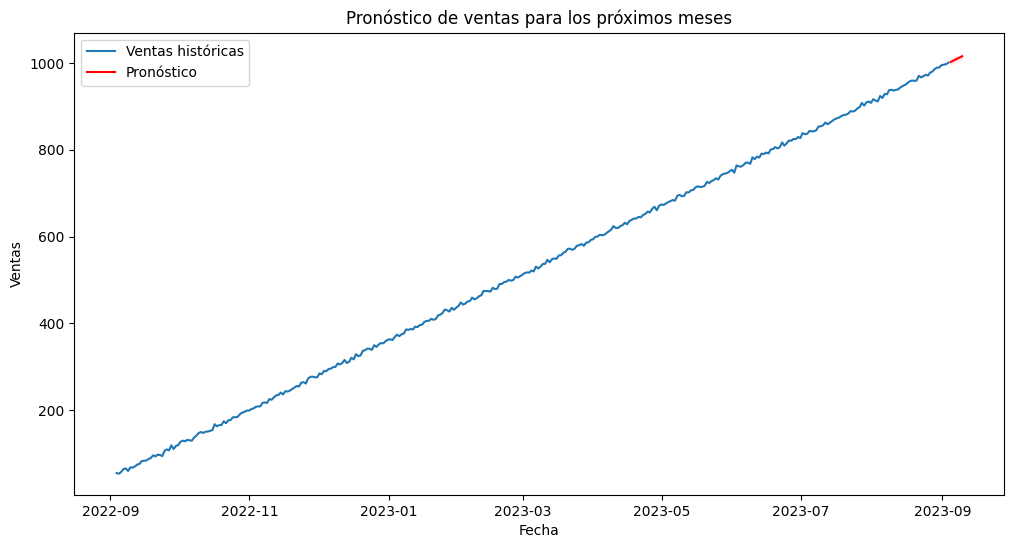

In [64]:
# Definir y ajustar el modelo ARIMA con el mejor orden encontrado
model = ARIMA(df['sales'], order=(0, 2, 3))
model_fit = model.fit()

forecast_steps = 6  # número de periodos futuros
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sales'], label='Ventas históricas')
plt.plot(forecast_mean.index, forecast_mean, label='Pronóstico', color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Pronóstico de ventas para los próximos meses')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()


Conclusión:
El modelo ARIMA(0, 2, 3), seleccionado por su menor AIC, proyecta un comportamiento 
de ventas estable en los próximos 6 periodos, con leves variaciones dentro del 
intervalo de confianza calculado. La amplitud de este intervalo indica que existe 
cierta incertidumbre, pero sin señales de cambios abruptos en la tendencia general.

En términos prácticos, los resultados sugieren que las ventas seguirán una línea 
similar a la observada en los últimos meses, lo que permite planificar inventario 
y recursos sin esperar crecimientos o caídas drásticas.

### Predicción sobre test y métricas
Qué hace: realiza la previsión para len(test) pasos, alinea índices, calcula RMSE, MAE y MAPE (en %). Devuelve las métricas como una serie para verlas.

In [65]:
# Celda 8: Predicción y evaluación
n_steps = len(test)
pred = final_res.forecast(steps=n_steps)
# Alinear índices para comparar correctamente
pred.index = test.index


# RMSE (calculado como raíz cuadrada del MSE)
rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
mape = (np.abs((test - pred) / test)).mean() * 100

pd.Series({"rmse": rmse, "mae": mae, "mape_pct": mape})

rmse        2.830066
mae         2.276427
mape_pct    0.253383
dtype: float64

### Gráfica: entrenamiento / real / predicción
Qué hace: dibuja la serie de entrenamiento, el test real y la predicción sobre el periodo de test.

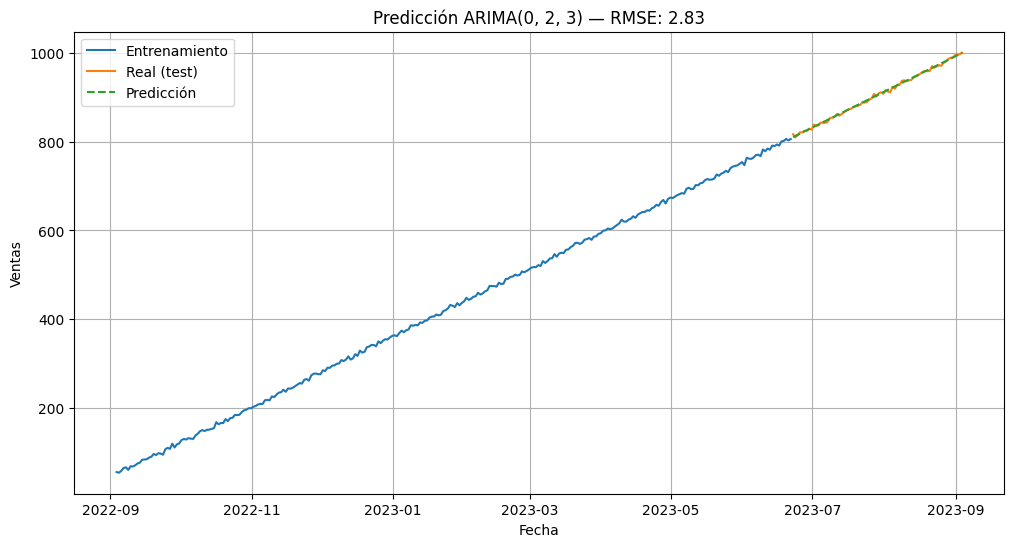

In [66]:
# Celda 9: Gráfico comparativo
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Real (test)')
plt.plot(pred.index, pred, label='Predicción', linestyle='--')
plt.legend()
plt.title(f'Predicción ARIMA{best_order} — RMSE: {rmse:.2f}')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()


### Guardar el Modelo

In [67]:
# Guardar el modelo
from pathlib import Path
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

save_path = models_dir / "modelo_arima.pkl"
try:
    # método nativo de statsmodels (si está disponible)
    final_res.save(save_path)
except Exception:
    import joblib
    joblib.dump(final_res, save_path)

# Mostrar existencia del archivo (True si guardado correctamente)
save_path.exists()


True

## Conclusión

El análisis y pronóstico del ritmo de ventas ha permitido estimar con mayor precisión la evolución de la demanda en los próximos meses. Los resultados confirman una tendencia creciente sostenida desde la creación de la empresa, lo que respalda la necesidad de planificar un aumento en la capacidad de almacenamiento.

Con esta proyección, la empresa cuenta con una base sólida para dimensionar adecuadamente el nuevo almacén en su próxima localización, evitando tanto la saturación prematura como el sobredimensionamiento innecesario. Este enfoque basado en datos favorece la optimización de recursos y garantiza que la reubicación se realice de forma eficiente y alineada con el crecimiento esperado del negocio.
